# Random Forest

Binary classification on California housing: `median_house_value > median`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_curve, auc)

data_df = pd.read_csv("housing.csv")
data_df['total_bedrooms'] = data_df['total_bedrooms'].fillna(data_df['total_bedrooms'].median())
data_df = pd.get_dummies(data_df, columns=['ocean_proximity'], dtype=float)

threshold = data_df['median_house_value'].median()
y = (data_df['median_house_value'] > threshold).astype(int).to_numpy()
X = data_df.drop(columns=['median_house_value']).to_numpy()
feature_names = list(data_df.drop(columns=['median_house_value']).columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, shuffle=True, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(13828, 13) (6812, 13)


## Baseline

200 trees, default depth — random forests are usually fine out of the box, so this sets a strong starting point.

In [2]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print(f"Train acc: {accuracy_score(y_train, rf.predict(X_train)):.4f}")
print(f"Test acc:  {accuracy_score(y_test, y_pred):.4f}")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=['Below', 'Above']))

Train acc: 1.0000
Test acc:  0.8922
[[3052  355]
 [ 379 3026]]
              precision    recall  f1-score   support

       Below       0.89      0.90      0.89      3407
       Above       0.90      0.89      0.89      3405

    accuracy                           0.89      6812
   macro avg       0.89      0.89      0.89      6812
weighted avg       0.89      0.89      0.89      6812



## n_estimators sweep

More trees = better accuracy with diminishing returns. Looking for where the curve flattens.

n=10    train=0.9925 test=0.8751
n=25    train=0.9995 test=0.8862


n=50    train=0.9999 test=0.8917


n=100   train=1.0000 test=0.8909


n=200   train=1.0000 test=0.8922


n=400   train=1.0000 test=0.8934


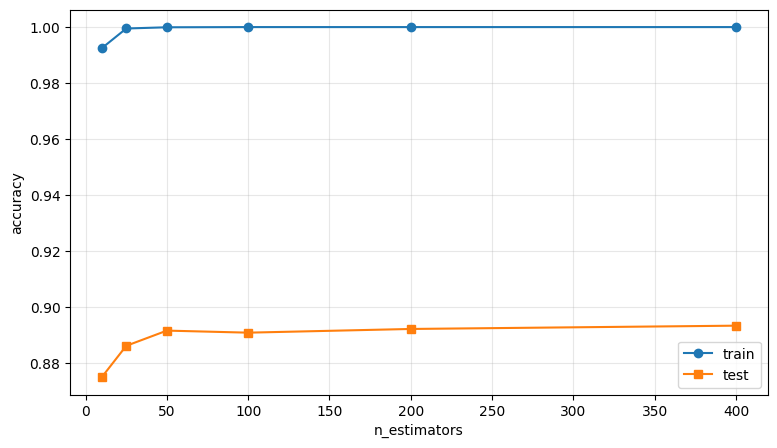

In [3]:
ns = [10, 25, 50, 100, 200, 400]
train_acc, test_acc = [], []

for n in ns:
    m = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    m.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, m.predict(X_train)))
    test_acc.append(accuracy_score(y_test, m.predict(X_test)))
    print(f"n={n:<5} train={train_acc[-1]:.4f} test={test_acc[-1]:.4f}")

plt.figure(figsize=(9, 5))
plt.plot(ns, train_acc, 'o-', label='train')
plt.plot(ns, test_acc, 's-', label='test')
plt.xlabel('n_estimators')
plt.ylabel('accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Depth sweep

Random forests tolerate deeper trees than a single tree because the averaging cancels overfitting on individual trees.

In [4]:
depths = [3, 5, 8, 12, 16, 20, None]
d_train, d_test = [], []

for d in depths:
    m = RandomForestClassifier(n_estimators=200, max_depth=d, random_state=42, n_jobs=-1)
    m.fit(X_train, y_train)
    d_train.append(accuracy_score(y_train, m.predict(X_train)))
    d_test.append(accuracy_score(y_test, m.predict(X_test)))
    print(f"depth={str(d):<5} train={d_train[-1]:.4f} test={d_test[-1]:.4f}")

depth=3     train=0.8260 test=0.8269


depth=5     train=0.8504 test=0.8463


depth=8     train=0.8903 test=0.8717


depth=12    train=0.9618 test=0.8865


depth=16    train=0.9967 test=0.8921


depth=20    train=1.0000 test=0.8934


depth=None  train=1.0000 test=0.8922


## Feature importance

Averaged across all trees — more stable than the importances from any single tree.

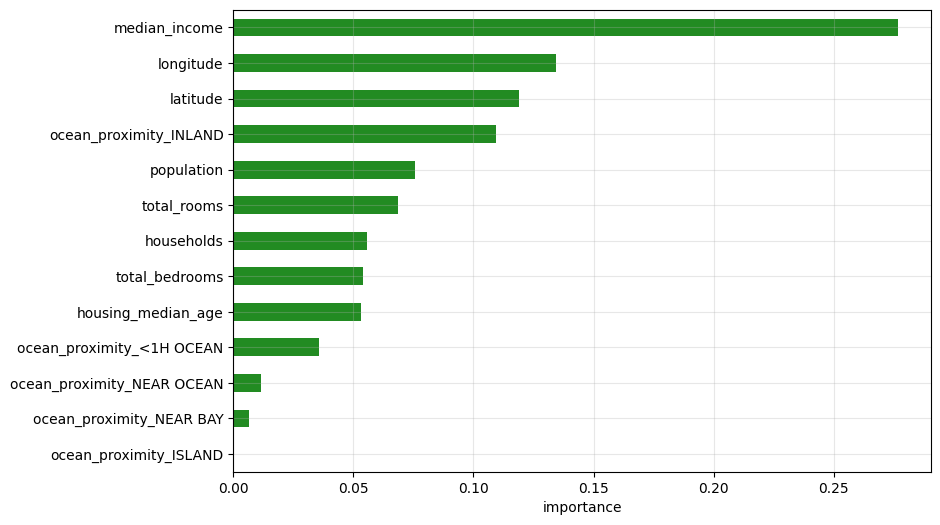

ocean_proximity_ISLAND        0.000099
ocean_proximity_NEAR BAY      0.006726
ocean_proximity_NEAR OCEAN    0.011448
ocean_proximity_<1H OCEAN     0.035724
housing_median_age            0.053092
total_bedrooms                0.054001
households                    0.055827
total_rooms                   0.068423
population                    0.075499
ocean_proximity_INLAND        0.109381
latitude                      0.118949
longitude                     0.134182
median_income                 0.276648
dtype: float64


In [5]:
importance = pd.Series(rf.feature_importances_, index=feature_names).sort_values()

plt.figure(figsize=(9, 6))
importance.plot(kind='barh', color='forestgreen')
plt.xlabel('importance')
plt.grid(alpha=0.3)
plt.show()

print(importance)

## OOB score

Each tree only trains on ~63% of the data due to bootstrap sampling, so the leftover ~37% acts as a built-in validation set. Free cross-validation.

In [6]:
rf_oob = RandomForestClassifier(n_estimators=200, oob_score=True,
                                bootstrap=True, random_state=42, n_jobs=-1)
rf_oob.fit(X_train, y_train)
print(f"OOB score: {rf_oob.oob_score_:.4f}")
print(f"Test acc:  {accuracy_score(y_test, rf_oob.predict(X_test)):.4f}")

OOB score: 0.8879
Test acc:  0.8922


## ROC

ROC + AUC on the best forest's predicted probabilities.

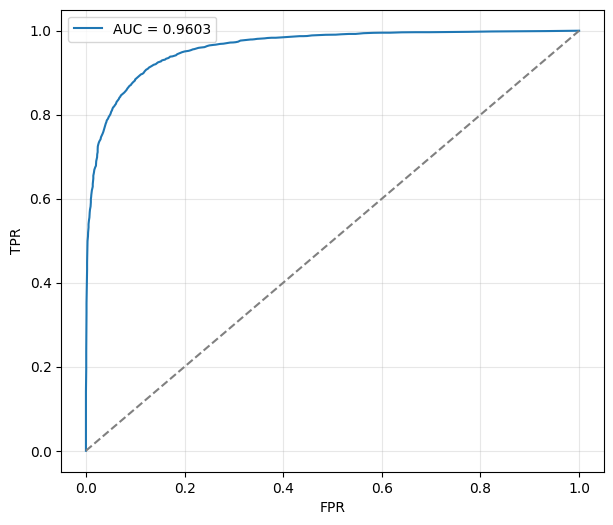

In [7]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## From-scratch (rice_ml)

My own random forest. Smaller and subsampled since each tree is slow.

In [8]:
from rice_ml.supervised_ml import RandomForestClassifier as RMRandomForest

rng_s = np.random.default_rng(42)
sub = rng_s.choice(len(X_train), 1500, replace=False)

rf_scratch = RMRandomForest(n_estimators=15, max_depth=5, seed=42).fit(X_train[sub], y_train[sub])
print(f"from-scratch (n=15, depth=5) acc: {rf_scratch.score(X_test, y_test):.4f}")
print(f"sklearn (n=200) acc:              {rf.score(X_test, y_test):.4f}")

from-scratch (n=15, depth=5) acc: 0.8130
sklearn (n=200) acc:              0.8922
